In [1]:
import numpy as np
import matplotlib.pyplot as plt

def extract_grayscale_histogram(images, bins=32):
    """
    Manually extracts standardized pixel intensity histogram features from 
    grayscale image matrices
    """
    if images.max() > 1.0:
        images = images / 255.0
        
    n_samples = images.shape[0]
    features = []
    
    for i in range(n_samples):
        img = images[i]
        # Calculate pixel frequency counts across intensity buckets from 0.0 to 1.0
        hist, _ = np.histogram(img, bins=bins, range=(0, 1))
        
        # Normalize the vector so it represents relative proportions
        total = np.sum(hist)
        features.append(hist / total if total > 0 else hist)
        
    return np.array(features)

def train_binary_svm(X, y, C=1.0, learning_rate=0.001, epochs=50, random_state=None):
    """
    Trains a single binary SVM model using vectorized batch gradient updates.
    """
    n_samples, n_features = X.shape
    rng = np.random.default_rng(random_state)
    
    w = rng.normal(0, 0.01, n_features)
    b = 0.0
    
    for epoch in range(epochs):
        margins = y * (np.dot(X, w) + b)
        misclassified = margins < 1
        
        dw = 2 * (1.0 / C) * w
        db = 0.0
        
        if np.any(misclassified):
            dw -= np.dot(y[misclassified], X[misclassified]) / n_samples
            db -= np.sum(y[misclassified]) / n_samples
            
        w -= learning_rate * dw
        b -= learning_rate * db
                
    return w, b

def fit_multiclass_svm(X, y, C=1.0, learning_rate=0.001, epochs=50, random_state=None):
    """
    Implements a One-vs-Rest multiclass execution loop.
    """
    X = np.array(X)
    y = np.array(y)
    unique_classes = np.unique(y)
    trained_models = {}
    
    for c in unique_classes:
        binary_y = np.where(y == c, 1, -1)
        w, b = train_binary_svm(X, binary_y, C=C, learning_rate=learning_rate, epochs=epochs, random_state=random_state)
        trained_models[c] = (w, b)
        
    return trained_models, unique_classes

def predict_multiclass_svm(X, trained_models, unique_classes):
    """
    Determines optimal class assignment designations utilizing maximal geometric margin scores.
    """
    X = np.array(X)
    n_samples = X.shape[0]
    scores = np.zeros((n_samples, len(unique_classes)))
    
    for i, c in enumerate(unique_classes):
        w, b = trained_models[c]
        scores[:, i] = np.dot(X, w) + b
        
    best_indices = np.argmax(scores, axis=1)
    return np.array([unique_classes[idx] for idx in best_indices])

def compute_classification_metrics(y_true, y_pred, unique_classes):
    """
    Manually calculates Precision, Recall, and F1-Score
    """
    precisions = []
    recalls = []
    f1_scores = []
    
    for c in unique_classes:
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))
        
        # Protect against division-by-zero errors
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)
        
    return np.mean(precisions), np.mean(recalls), np.mean(f1_scores)

def plot_metrics_with_error_bars(final_stats, title):
    """
    Plots a bar chart of classification metrics with standard error bars.
    """
    metrics = list(final_stats.keys())
    means = [final_stats[m]["mean"] for m in metrics]
    stds = [final_stats[m]["sem"] for m in metrics]  # Using SEM for the error bars

    plt.figure(figsize=(10, 6))
    plt.bar(metrics, means, yerr=stds, capsize=10, edgecolor="black", color="#3498db")
    plt.title(title)
    plt.ylabel("Score")
    plt.ylim(0, 1.1)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

Final training dataset size: 109309 images.

======== Outer Fold 1 ==========
Params: {'C': 0.001} | Inner Validation Acc: 0.0809
Params: {'C': 0.01} | Inner Validation Acc: 0.4700
Params: {'C': 0.1} | Inner Validation Acc: 0.4700
Best Parameter Selected: {'C': 0.01}
Fold 1 | Clean Acc: 0.4713 | Degraded Acc: 0.4713

======== Outer Fold 2 ==========
Params: {'C': 0.001} | Inner Validation Acc: 0.0812
Params: {'C': 0.01} | Inner Validation Acc: 0.4701
Params: {'C': 0.1} | Inner Validation Acc: 0.4701
Best Parameter Selected: {'C': 0.01}
Fold 2 | Clean Acc: 0.4703 | Degraded Acc: 0.4703

======== Outer Fold 3 ==========
Params: {'C': 0.001} | Inner Validation Acc: 0.0810
Params: {'C': 0.01} | Inner Validation Acc: 0.4701
Params: {'C': 0.1} | Inner Validation Acc: 0.4701
Best Parameter Selected: {'C': 0.01}
Fold 3 | Clean Acc: 0.4704 | Degraded Acc: 0.4704

======== Outer Fold 4 ==========
Params: {'C': 0.001} | Inner Validation Acc: 0.0812
Params: {'C': 0.01} | Inner Validation Acc: 0.47

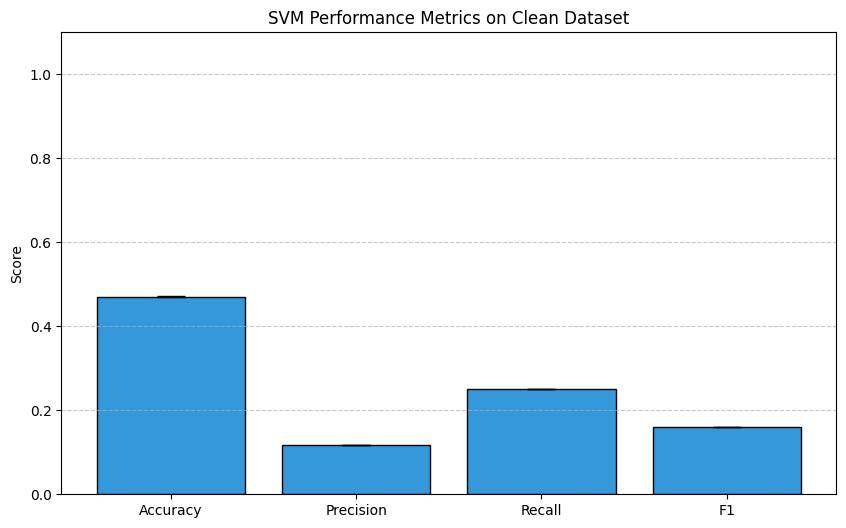

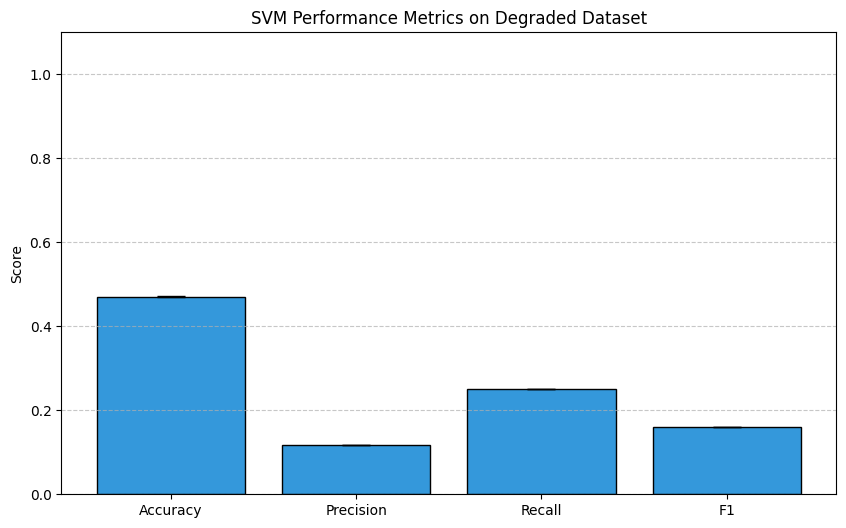

In [3]:
import os
import sys
import numpy as np
import pandas as pd
import cv2

src_path = os.path.abspath(os.path.join("..", "src"))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from cross_validation import stratified_kfold

parent_dir = os.path.abspath("..")
metadata_path = os.path.join(parent_dir, "data", "image_metadata.csv")
processed_dir = os.path.join(parent_dir, "data", "processed")
degraded_dir = os.path.abspath(os.path.join("..", "data", "degraded"))

df = pd.read_csv(metadata_path, index_col=0)
if df.index.name:
    df.index.name = df.index.name.strip()

print(f"Final training dataset size: {len(df)} images.")

features_list = []

# Separate list to collect intensity features from degraded frames
degraded_features_list = []

for _, row in df.iterrows():
    img_path = os.path.join(processed_dir, row["filename"])
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        raise FileNotFoundError(f"Could not load image at {img_path}.")
    
    # Extract feature for one image at a time
    single_feature = extract_grayscale_histogram(np.array([img]), bins=32)[0]
    features_list.append(single_feature)
    
    # Load corresponding degraded frame and stream its feature extraction
    deg_img_path = os.path.join(degraded_dir, row["filename"])
    deg_img = cv2.imread(deg_img_path, cv2.IMREAD_GRAYSCALE)
    if deg_img is None:
        raise FileNotFoundError(f"Could not load degraded image at {deg_img_path}.")
    single_deg_feature = extract_grayscale_histogram(np.array([deg_img]), bins=32)[0]
    degraded_features_list.append(single_deg_feature)

X_features = np.array(features_list)
X_degraded_features = np.array(degraded_features_list)

y_text = df.index.values       
patient_ids = df["patient_id"].values

# Code categorical labels to structural numbers for loss evaluation equations
unique_text_classes = ['CNV', 'DME', 'DRUSEN', 'NORMAL']
class_to_idx = {cls: idx for idx, cls in enumerate(unique_text_classes)}
y = np.array([class_to_idx[label] for label in y_text])
numerical_classes = np.array([0, 1, 2, 3])

# Initialise the outer loop
splits = stratified_kfold(X_features, y, groups=patient_ids, n_splits=10, shuffle=True, random_state=42)

outer_accuracies = []
outer_precisions = []
outer_recalls = []
outer_f1s = []

# Log matrices dedicated to preserving performance markers for degraded sets
deg_outer_accuracies = []
deg_outer_precisions = []
deg_outer_recalls = []
deg_outer_f1s = []

for fold_idx, (train_idx, test_idx) in enumerate(splits):    
    # Outer fold tracking 
    print(f"\n======== Outer Fold {fold_idx + 1} ==========")
    
    X_train, y_train = X_features[train_idx], y[train_idx]
    train_groups = patient_ids[train_idx]  
    X_test, y_test = X_features[test_idx], y[test_idx]
    # Slice matching partition slice for adversarial evaluation data
    X_test_deg = X_degraded_features[test_idx]
    
    # Nested hyperparameter tuning 
    inner_splits = stratified_kfold(X_train, y_train, groups=train_groups, n_splits=3, shuffle=True, random_state=42)
    
    C_candidates = [0.001, 0.01, 0.1]
    best_C = None
    best_inner_score = -1.0
    
    for C_val in C_candidates:
        inner_fold_scores = []
        for inner_train_idx, val_idx in inner_splits:
            X_inner_train, X_val = X_train[inner_train_idx], X_train[val_idx]
            y_inner_train, y_val = y_train[inner_train_idx], y_train[val_idx]
            
            models, classes = fit_multiclass_svm(
                X_inner_train, y_inner_train, 
                C=C_val, learning_rate=0.01, epochs=20, random_state=42
            )
            preds = predict_multiclass_svm(X_val, models, classes)
            inner_fold_scores.append(np.mean(preds == y_val))
            
        mean_inner_score = np.mean(inner_fold_scores)
        # Track parameter search performance
        print(f"Params: {{'C': {C_val}}} | Inner Validation Acc: {mean_inner_score:.4f}")
        
        if mean_inner_score > best_inner_score:
            best_inner_score = mean_inner_score
            best_C = C_val
            
    print(f"Best Parameter Selected: {{'C': {best_C}}}")
    
    # Evaluation on unseen data
    final_models, final_classes = fit_multiclass_svm(
        X_train, y_train, 
        C=best_C, learning_rate=0.01, epochs=50, random_state=42
    )
    
    final_preds = predict_multiclass_svm(X_test, final_models, final_classes)
    
    # Compute and preserve performance scores
    fold_acc = np.mean(final_preds == y_test)
    fold_prec, fold_rec, fold_f1 = compute_classification_metrics(y_test, final_preds, numerical_classes)
    
    outer_accuracies.append(fold_acc)
    outer_precisions.append(fold_prec)
    outer_recalls.append(fold_rec)
    outer_f1s.append(fold_f1)
    
    final_deg_preds = predict_multiclass_svm(X_test_deg, final_models, final_classes)
    
    # Compute result metrics for the degraded image subset
    deg_fold_acc = np.mean(final_deg_preds == y_test)
    deg_fold_prec, deg_fold_rec, deg_fold_f1 = compute_classification_metrics(y_test, final_deg_preds, numerical_classes)
    
    # Store tracking parameters into structural logs
    deg_outer_accuracies.append(deg_fold_acc)
    deg_outer_precisions.append(deg_fold_prec)
    deg_outer_recalls.append(deg_fold_rec)
    deg_outer_f1s.append(deg_fold_f1)
    
    print(f"Fold {fold_idx + 1} | Clean Acc: {fold_acc:.4f} | Degraded Acc: {deg_fold_acc:.4f}")

n_folds = len(splits)

clean_stats = {
    "Accuracy": {"mean": np.mean(outer_accuracies), "sem": np.std(outer_accuracies) / np.sqrt(n_folds)},
    "Precision": {"mean": np.mean(outer_precisions), "sem": np.std(outer_precisions) / np.sqrt(n_folds)},
    "Recall": {"mean": np.mean(outer_recalls), "sem": np.std(outer_recalls) / np.sqrt(n_folds)},
    "F1": {"mean": np.mean(outer_f1s), "sem": np.std(outer_f1s) / np.sqrt(n_folds)}
}

deg_stats = {
    "Accuracy": {"mean": np.mean(deg_outer_accuracies), "sem": np.std(deg_outer_accuracies) / np.sqrt(n_folds)},
    "Precision": {"mean": np.mean(deg_outer_precisions), "sem": np.std(deg_outer_precisions) / np.sqrt(n_folds)},
    "Recall": {"mean": np.mean(deg_outer_recalls), "sem": np.std(deg_outer_recalls) / np.sqrt(n_folds)},
    "F1": {"mean": np.mean(deg_outer_f1s), "sem": np.std(deg_outer_f1s) / np.sqrt(n_folds)}
}

# Results for processed dataset evaluation
print("\n" + "="*40 + "\nFinal Processed Results\n" + "="*40)
print(f"Accuracy:  {clean_stats['Accuracy']['mean']:.4f} ± {clean_stats['Accuracy']['sem']:.4f}")
print(f"Precision: {clean_stats['Precision']['mean']:.4f} ± {clean_stats['Precision']['sem']:.4f}")
print(f"Recall:    {clean_stats['Recall']['mean']:.4f} ± {clean_stats['Recall']['sem']:.4f}")
print(f"F1:        {clean_stats['F1']['mean']:.4f} ± {clean_stats['F1']['sem']:.4f}")

# Results for the degraded dataset evaluation
print("\n" + "="*40 + "\nFinal Degraded Results\n" + "="*40)
print(f"Degraded Accuracy:  {deg_stats['Accuracy']['mean']:.4f} ± {deg_stats['Accuracy']['sem']:.4f}")
print(f"Degraded Precision: {deg_stats['Precision']['mean']:.4f} ± {deg_stats['Precision']['sem']:.4f}")
print(f"Degraded Recall:    {deg_stats['Recall']['mean']:.4f} ± {deg_stats['Recall']['sem']:.4f}")
print(f"Degraded F1:        {deg_stats['F1']['mean']:.4f} ± {deg_stats['F1']['sem']:.4f}")

# Generate plots with error bars 
plot_metrics_with_error_bars(clean_stats, "SVM Performance Metrics on Clean Dataset")
plot_metrics_with_error_bars(deg_stats, "SVM Performance Metrics on Degraded Dataset")